In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from xgboost import XGBClassifier
from joblib import load, dump
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import brier_score_loss, roc_auc_score, RocCurveDisplay, PrecisionRecallDisplay
import random
import shap
shap.initjs()

In [2]:
X_train, y_train = load("C:/Users/Pratik/DS/credit-risk-ml/models/train_data.joblib")
X_test, y_test = load("C:/Users/Pratik/DS/credit-risk-ml/models/test_data.joblib")

In [3]:
preprocessor = load("C:/Users/Pratik/DS/credit-risk-ml/models/preprocessor_fit.joblib")

X_train_processed = preprocessor.transform(X_train) 
X_test_processed = preprocessor.transform(X_test)

In [4]:
xgb_model = XGBClassifier(
    n_estimators = 500,
    max_depth = 6,
    learning_rate = 0.05,
    scale_pos_weight = 9,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state = 42,
    eval_metric = 'auc'
)

xgb_model.fit(X_train_processed, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [5]:
y_pred_xgb = xgb_model.predict(X_test_processed)
y_prob_xgb = xgb_model.predict_proba(X_test_processed)[:, 1]
print('ROC-AUC', roc_auc_score(y_test,y_prob_xgb))

ROC-AUC 0.7599123558211096


In [6]:
# Calculating ECE
def expected_calibration_error(y_true, y_prob, n_bins=10):
    y_prob = np.clip(y_prob, 0, 1 - 1e-8)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(y_prob, bins) - 1

    ece = 0.0
    for m in range(n_bins):
        bin_mask = (bin_ids == m)
        if np.any(bin_mask):
            bin_acc = y_true[bin_mask].mean()
            bin_conf = y_prob[bin_mask].mean()
            ece += np.sum(bin_mask) / len(y_true) * np.abs(bin_acc - bin_conf)
    return ece

ece = expected_calibration_error(y_test, y_prob_xgb)
print(f"Expected Calibration Error (ECE): {ece}")

# Brier Score
brier = brier_score_loss(y_test, y_prob_xgb)
print(f"Brier score: {brier}")


Expected Calibration Error (ECE): 0.2520823273545189
Brier score: 0.1487654149532318


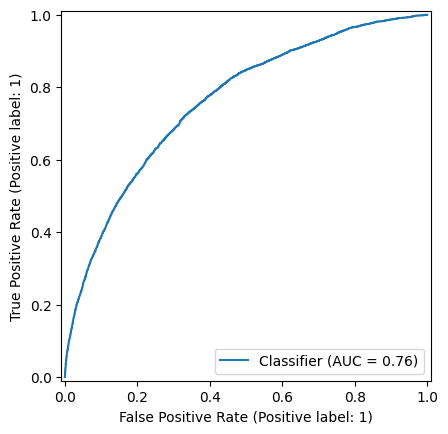

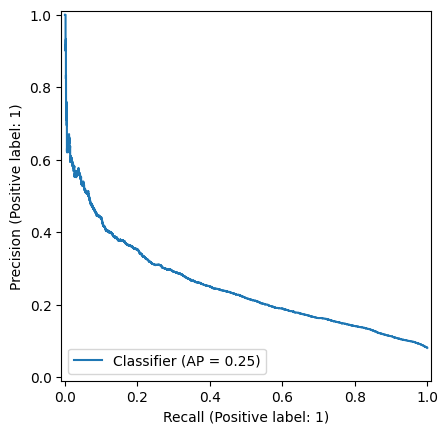

In [7]:
# Plots
roc_disp = RocCurveDisplay.from_predictions(y_test, y_prob_xgb)
plt.savefig('C:/Users/Pratik/DS/credit-risk-ml/reports/figures/roc_disp_xgb.png',dpi=300,bbox_inches='tight')
plt.show()

pr_disp = PrecisionRecallDisplay.from_predictions(y_test, y_prob_xgb)
plt.savefig('C:/Users/Pratik/DS/credit-risk-ml/reports/figures/pr_disp_xgb.png',dpi=300,bbox_inches='tight')
plt.show()

XGBoost improved discrimination (AUC 0.744 → 0.760) but had much worse calibration (ECE 0.041 → 0.252), demonstrating that a more powerful model isn't always better for decision making when you need reliable probabilities, but this is also not calibrated yet, which is a known issue of gradient boosting models, so we would be doing that next.

In [8]:
# Calibrating XGBoost

xgb_calibrated = CalibratedClassifierCV(
    xgb_model,
    method='sigmoid',
    cv= 5
)

xgb_calibrated.fit(X_train_processed, y_train)
y_prob_xgb_cal = xgb_calibrated.predict_proba(X_test_processed)[:, 1]


print('ROC-AUC:', roc_auc_score(y_test, y_prob_xgb_cal))
ece_cal = expected_calibration_error(y_test, y_prob_xgb_cal)
print(f"ECE Calibrated: {ece_cal}")
brier_cal = brier_score_loss(y_test, y_prob_xgb_cal)
print(f"Brier Calibrated: {brier_cal}")

ROC-AUC: 0.7631236085119093
ECE Calibrated: 0.0015021531003789057
Brier Calibrated: 0.06755248879497273


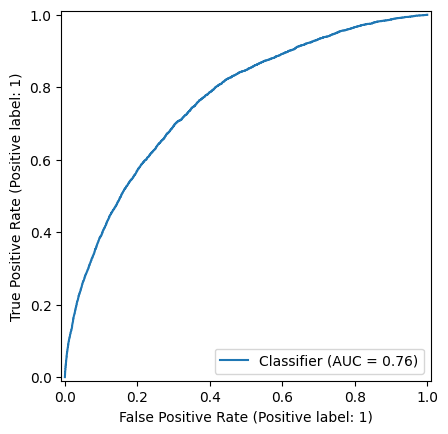

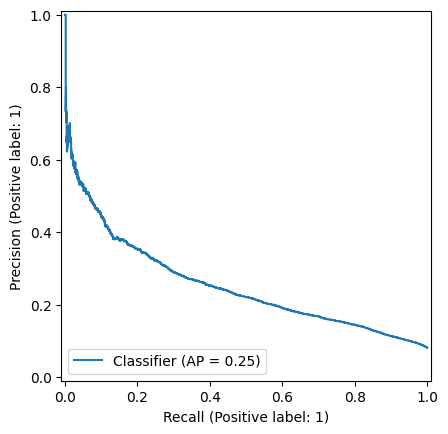

In [9]:
# Plots
roc_disp_cal = RocCurveDisplay.from_predictions(y_test, y_prob_xgb_cal)
plt.savefig('C:/Users/Pratik/DS/credit-risk-ml/reports/figures/roc_disp_xgb_cal.png',dpi=300,bbox_inches='tight')
plt.show()

pr_disp_cal = PrecisionRecallDisplay.from_predictions(y_test, y_prob_xgb_cal)
plt.savefig('C:/Users/Pratik/DS/credit-risk-ml/reports/figures/pr_disp_xgb_cal.png',dpi=300,bbox_inches='tight')
plt.show()

In [10]:
# Model Comparison Table

logreg_baseline = load('C:/Users/Pratik/DS/credit-risk-ml/models/logreg_baseline.joblib')
logreg_platt = load('C:/Users/Pratik/DS/credit-risk-ml/models/logreg_platt.joblib')

# Generate Probabilities for Logistic Regression Models
y_prob_logreg = logreg_baseline.predict_proba(X_test)[:, 1]
y_prob_logreg_platt = logreg_platt.predict_proba(X_test)[:, 1]

# Build comparison table
results = {
    "Model": [
        "Logistic Regression",
        "Logistic Regression (Calibrated)",
        "XGBoost",
        "XGBoost (Calibrated)"
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_logreg),
        roc_auc_score(y_test, y_prob_logreg_platt),
        roc_auc_score(y_test, y_prob_xgb),
        roc_auc_score(y_test, y_prob_xgb_cal)
    ],
    "Brier Score": [
        brier_score_loss(y_test, y_prob_logreg),
        brier_score_loss(y_test, y_prob_logreg_platt),
        brier_score_loss(y_test, y_prob_xgb),
        brier_score_loss(y_test, y_prob_xgb_cal)
    ],
    "ECE": [
        expected_calibration_error(y_test, y_prob_logreg),
        expected_calibration_error(y_test, y_prob_logreg_platt),
        expected_calibration_error(y_test, y_prob_xgb),
        expected_calibration_error(y_test, y_prob_xgb_cal)
    ]
}

model_comparison_df = pd.DataFrame(results)
model_comparison_df = model_comparison_df.round(4)
print(model_comparison_df)

model_comparison_df.to_csv("C:/Users/Pratik/DS/credit-risk-ml/reports/summary_tables/model_comparison_df.csv")

                              Model  ROC-AUC  Brier Score     ECE
0               Logistic Regression   0.7433       0.2049  0.3462
1  Logistic Regression (Calibrated)   0.7435       0.0688  0.0018
2                           XGBoost   0.7599       0.1488  0.2521
3              XGBoost (Calibrated)   0.7631       0.0676  0.0015


In [11]:
# Get all feature names directly from fitted preprocessor
all_feature_names = preprocessor.get_feature_names_out()
print(f"Total feature names: {len(all_feature_names)}")
print(all_feature_names[:10])  # preview first 10

Total feature names: 144
['num__AMT_INCOME_TOTAL' 'num__AGE_YEARS' 'num__EMPLOYED_YEARS'
 'num__EXT_SOURCE_1' 'num__EXT_SOURCE_2' 'num__EXT_SOURCE_3'
 'num__INCOME_RISK' 'num__ORG_RISK'
 'cat__NAME_CONTRACT_TYPE_Revolving loans'
 'cat__NAME_EDUCATION_TYPE_Higher education']


In [12]:
# Clean up feature names - remove prefixes
clean_feature_names = [name.split('__')[1] for name in all_feature_names]

# Build DataFrame
X_test_df = pd.DataFrame(X_test_processed, columns=clean_feature_names)

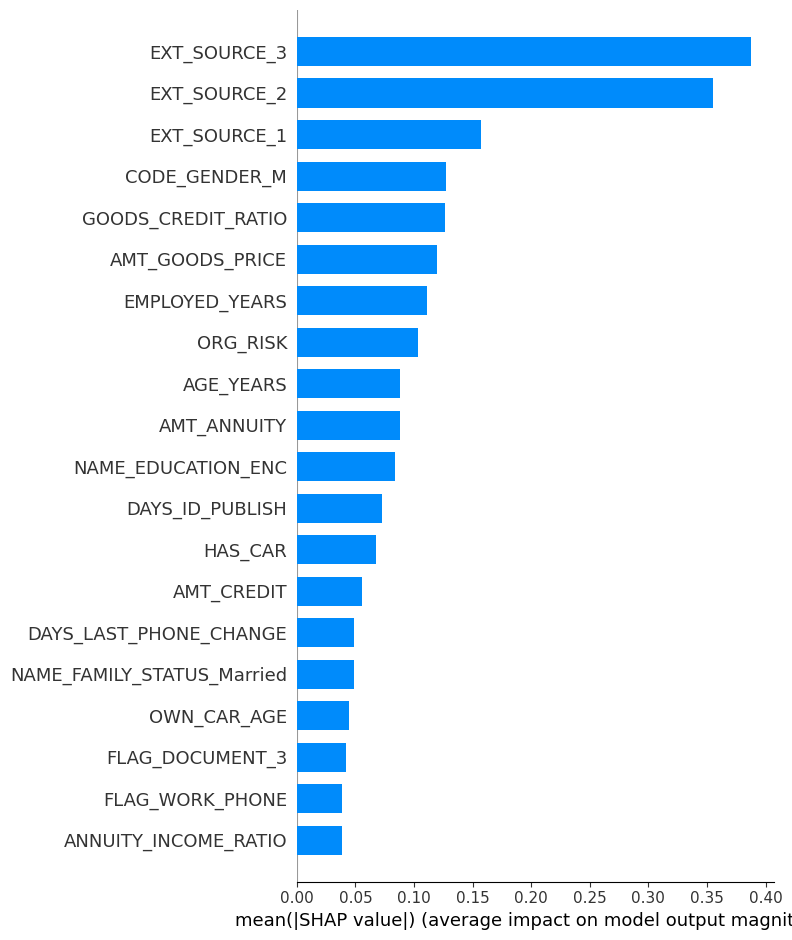

In [13]:
# Shap 
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_df)

shap.summary_plot(shap_values, X_test_df, plot_type = 'bar')
plt.savefig("../reports/figures/shap_xgb_feature_importance.png", 
            bbox_inches='tight', dpi=150)
plt.close()

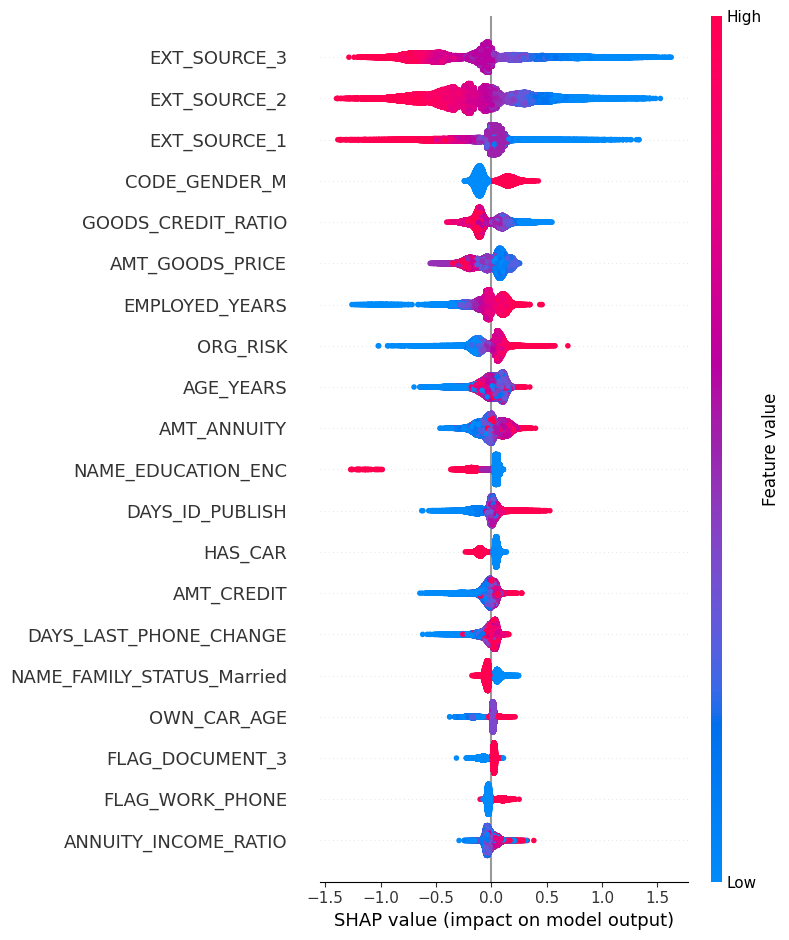

In [14]:
shap.summary_plot(shap_values, X_test_df, show=False)
plt.savefig("../reports/figures/shap_xgb_feature_importance_bee.png", 
            bbox_inches='tight', dpi=150)
plt.show()


In [15]:
# Saving Models
dump(xgb_model, "C:/Users/Pratik/DS/credit-risk-ml/models/xgb_model.joblib")
dump(xgb_calibrated, "C:/Users/Pratik/DS/credit-risk-ml/models/xgb_calibrated.joblib")

['C:/Users/Pratik/DS/credit-risk-ml/models/xgb_calibrated.joblib']

In [16]:
# Assigning Risk Buckets 
def assign_risk_buckets(prob):
    if prob < 0.05:
        return 'Low - Approve'
    elif prob < 0.16:
        return 'Medium - Approve with conditions'
    elif prob < 0.45:
        return 'High - Manual Review'
    else:
        return 'Very High - Reject'

# Applying to test set
results_df = pd.DataFrame({'predicted_pd':y_prob_xgb_cal, 'actual':y_test.values})
results_df['risk_bucket'] = results_df['predicted_pd'].apply(assign_risk_buckets)

#Summary
print(results_df['risk_bucket'].value_counts(),'\n')
print(results_df.groupby('risk_bucket')['actual'].mean().round(3))
results_df.to_csv('../reports/summary_tables/risk_bucket_summary_xgb')



risk_bucket
Low - Approve                       31186
Medium - Approve with conditions    22053
High - Manual Review                 8228
Very High - Reject                     36
Name: count, dtype: int64 

risk_bucket
High - Manual Review                0.246
Low - Approve                       0.027
Medium - Approve with conditions    0.094
Very High - Reject                  0.667
Name: actual, dtype: float64


In [28]:
# Applicant Example  
sample_idx = random.randint(0, len(y_prob_xgb_cal) - 1)
sample_prob = y_prob_xgb_cal[sample_idx]
sample_bucket = assign_risk_buckets(sample_prob)

print(f"Applicant Index: {sample_idx}")
print(f'Predicted PD: {sample_prob:.3f}')
print(f"Risk Bucket: {sample_bucket}")
print(f"Actual Outcome: {'Default' if y_test.values[sample_idx] == 1 else 'No Default'}")

shap.force_plot(
    base_value=explainer.expected_value, 
    shap_values=shap_values[sample_idx, :], 
    features=X_test_df.iloc[sample_idx, :],
    matplotlib=False
)


Applicant Index: 23764
Predicted PD: 0.407
Risk Bucket: High - Manual Review
Actual Outcome: Default
